# Comparing LFP Theta power for correct and incorrect trials

working with the 4Hz model data, generated for delay=400

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import lfp_utils as lu
from bootstrap_method import *
import population_utils as pu



2025-10-07 13:46:30.483395: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 13:46:30.492700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-07 13:46:30.503012: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 13:46:30.506009: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 13:46:30.514339: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 400
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
# theta8_dirs = [m for m in model_dirs if '8.0' in m] # 8Hz models only

print(f'Number of 4Hz models: {len(theta4_dirs)}')

perfs = []
for model_name in theta4_dirs:
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    perfs.append(np.mean(trial_perfs))
    print(f'Model {model_name}, performance: {np.mean(trial_perfs):.2f}')

Number of 4Hz models: 22
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, performance: 0.78
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, performance: 0.99
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, performance: 0.99
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, performance: 0.56
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726, performance: 0.97
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802, performance: 0.97
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736, performance: 0.68
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559, performance: 0.89
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527, performance: 0.86
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653, performance: 0.91
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450, performance: 0.98
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025

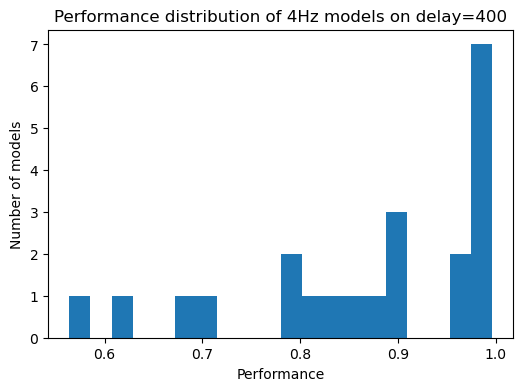

In [4]:
plt.figure(figsize=(6,4))
plt.hist(perfs, bins=20)
plt.xlabel('Performance')
plt.ylabel('Number of models')
plt.title('Performance distribution of 4Hz models on delay=400')
plt.show()

### plots for single model (just experimenting)

In [4]:
# choose a model to visualize for now
model_name = theta4_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_exc0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_stimon100.pkl', '/home/nuttidalab/Documents/renee/lfp_input_mo

In [5]:
# neural data
lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)

In [14]:
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
_,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

In [24]:
times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)

print(times_fs)
print(times_real)
print(fs_dict)

{'stim1_on': 255.0, 'stim1_off': 505.0, 'stim2_on': 2505.0, 'stim2_off': 2755.0, 'T': 3255.0, 'delay': 2000.0, 'stim_dur': 250.0, 'fs': 1000}
{'stim1_on': 0.255, 'stim1_off': 0.505, 'stim2_on': 2.505, 'stim2_off': 2.755, 'T': 3.255, 'delay': 2.0, 'stim_dur': 0.25}
{'rate': 200, 'spk': 20000, 'ds': 1000}


In [25]:
bandpower_corr.shape

(846, 3255)

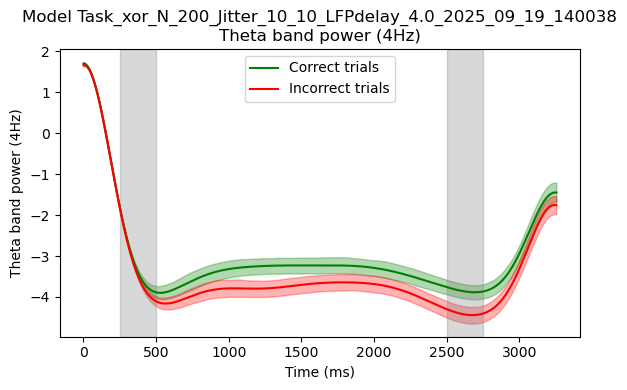

In [ ]:
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

fs_ds = int(fs_dict['ds'])
fs_rate = int(fs_dict['rate'])

power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()

t1_avg, t1_CI, t2_avg, t2_CI, _, _, p_diff = fnc_time_bootstrap_optimized_retX(bandpower_corr, bandpower_incorr,
                                                            nboot, CI_int, random_seed=random_seed)

plt.figure(figsize=(6,4))
plt.plot(t1_avg.mean(axis=1), label='Correct trials', color='green')
plt.fill_between(np.arange(bandpower_corr.shape[1]), 
                 t1_CI[:,0], t1_CI[:,1], alpha=0.3, color='green')
plt.plot(t2_avg.mean(axis=1), label='Incorrect trials', color='red')
plt.fill_between(np.arange(bandpower_incorr.shape[1]), 
                    t2_CI[:,0], t2_CI[:,1], alpha=0.3, color='red')
plt.axvspan(250, 500, color='gray', alpha=0.3)
plt.axvspan(2500, 2750, color='gray', alpha=0.3)
plt.title(f'Model {model_name}\nTheta band power (4Hz)')
plt.xlabel('Time (ms)')
plt.ylabel('Theta band power (4Hz)')
plt.legend()
plt.tight_layout()
plt.show()

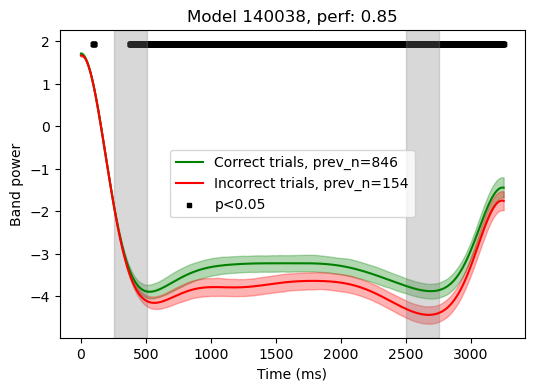

In [31]:
importlib.reload(lu)

lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, all_models_dir=all_models_dir)

### apply to multiple models

In [14]:
trial_labels, trial_perfs = ld.load_bhv_data(theta4_dirs[12], condn_phrase, condn_num, all_models_dir=all_models_dir)

In [16]:
trial_perfs.mean()

0.966

Skipping model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450 due to insufficient incorrect trials, n=1


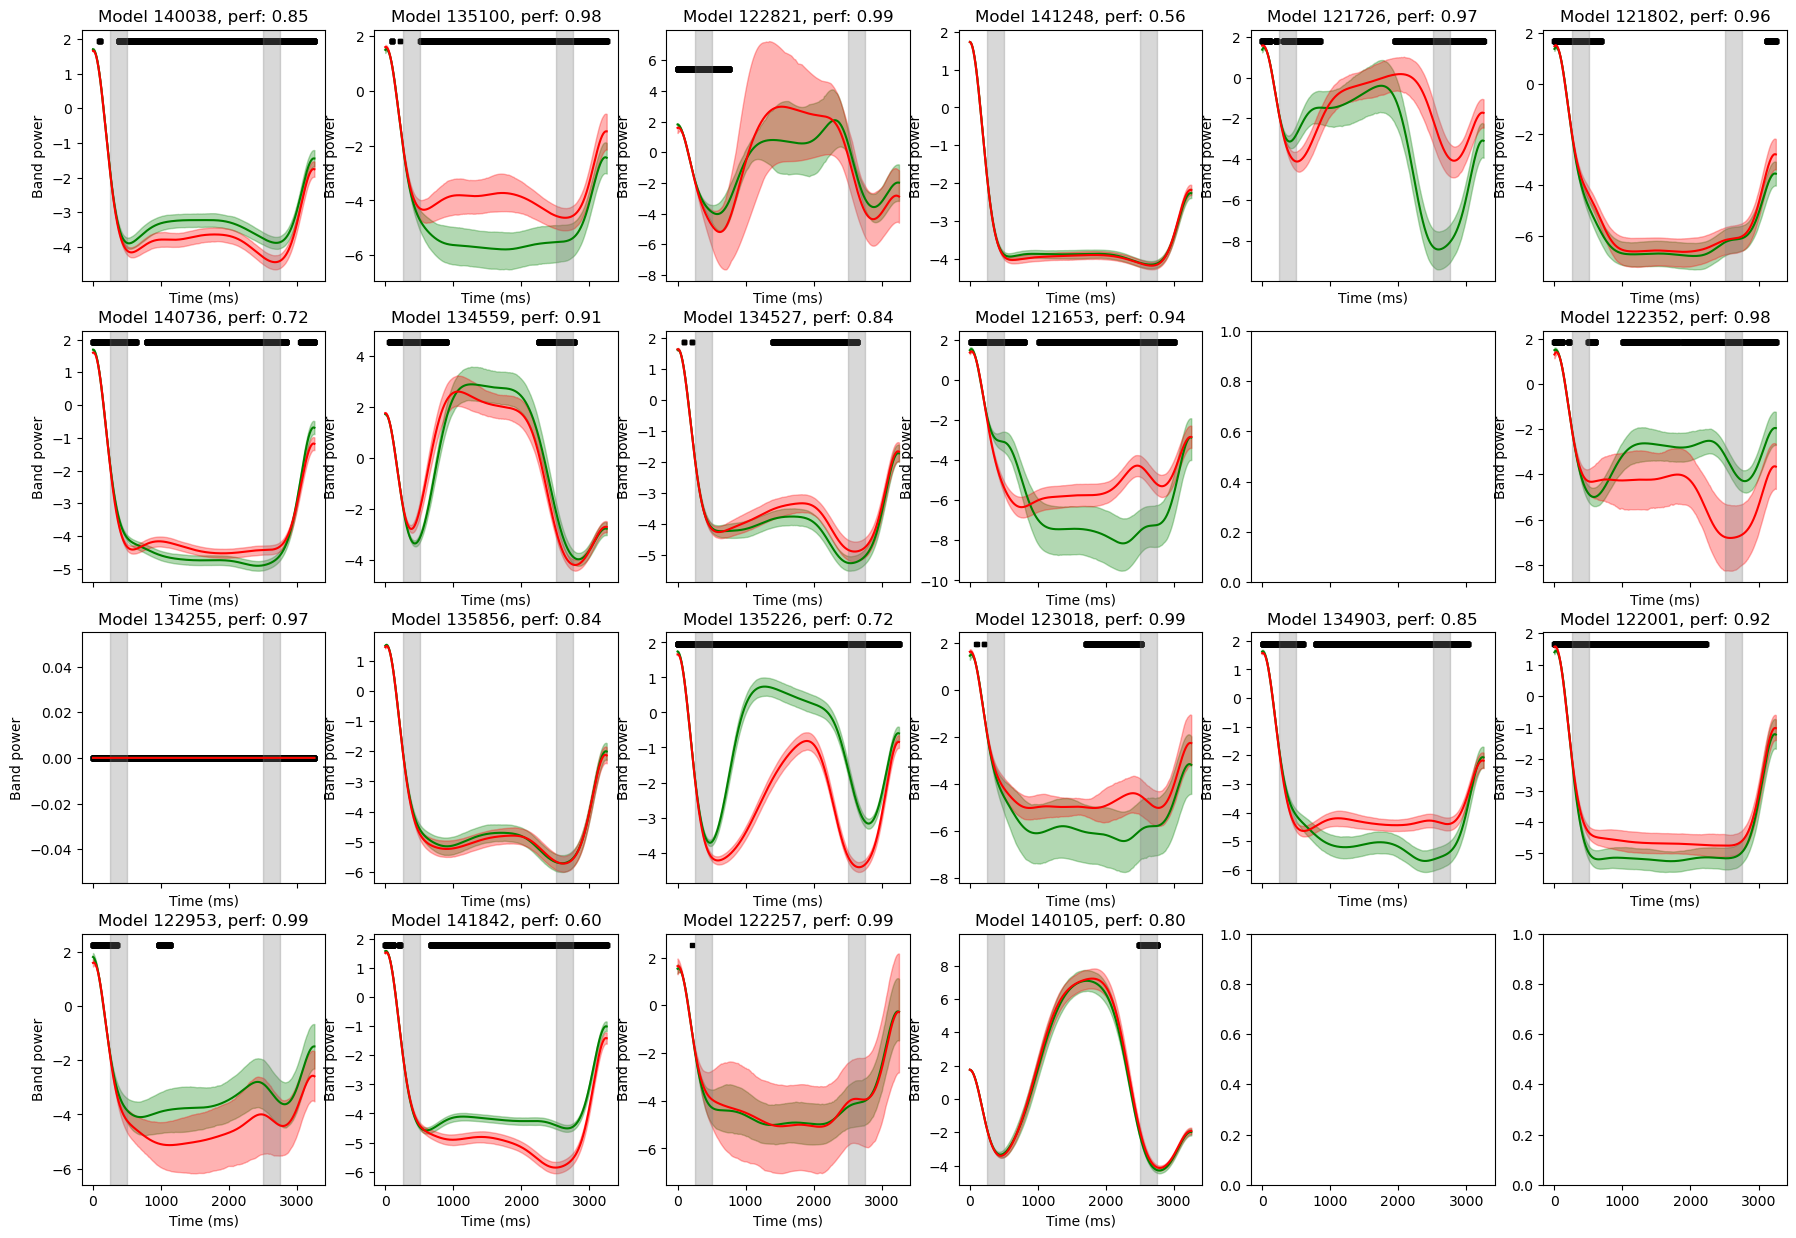

In [13]:
importlib.reload(lu)

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

corrs = []
incorrs = []
corr_CIs = []
incorr_CIs = []
ps = []

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_dirs):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    # split by correct vs incorrect trials
    bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
    bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
    
    if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
        print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
        continue
    
    # plot with bootstrap CIs
    _, corr, incorr, corr_CI, incorr_CI, p = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                ax = axs[i_model], all_models_dir=all_models_dir)
    
    corrs.append(corr)
    incorrs.append(incorr)
    corr_CIs.append(corr_CI)
    incorr_CIs.append(incorr_CI)
    ps.append(p)
    

### apply to multiple, but only if btwn 70-95% accuracy

In [17]:
theta4_models_select, theta4_perfs = ld.get_models_by_perf(low_cutoff=0.7, high_cutoff=0.95, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              model_list = theta4_dirs,
                                              all_models_dir = all_models_dir)

Found 10 models with performance between 0.7 and 0.95


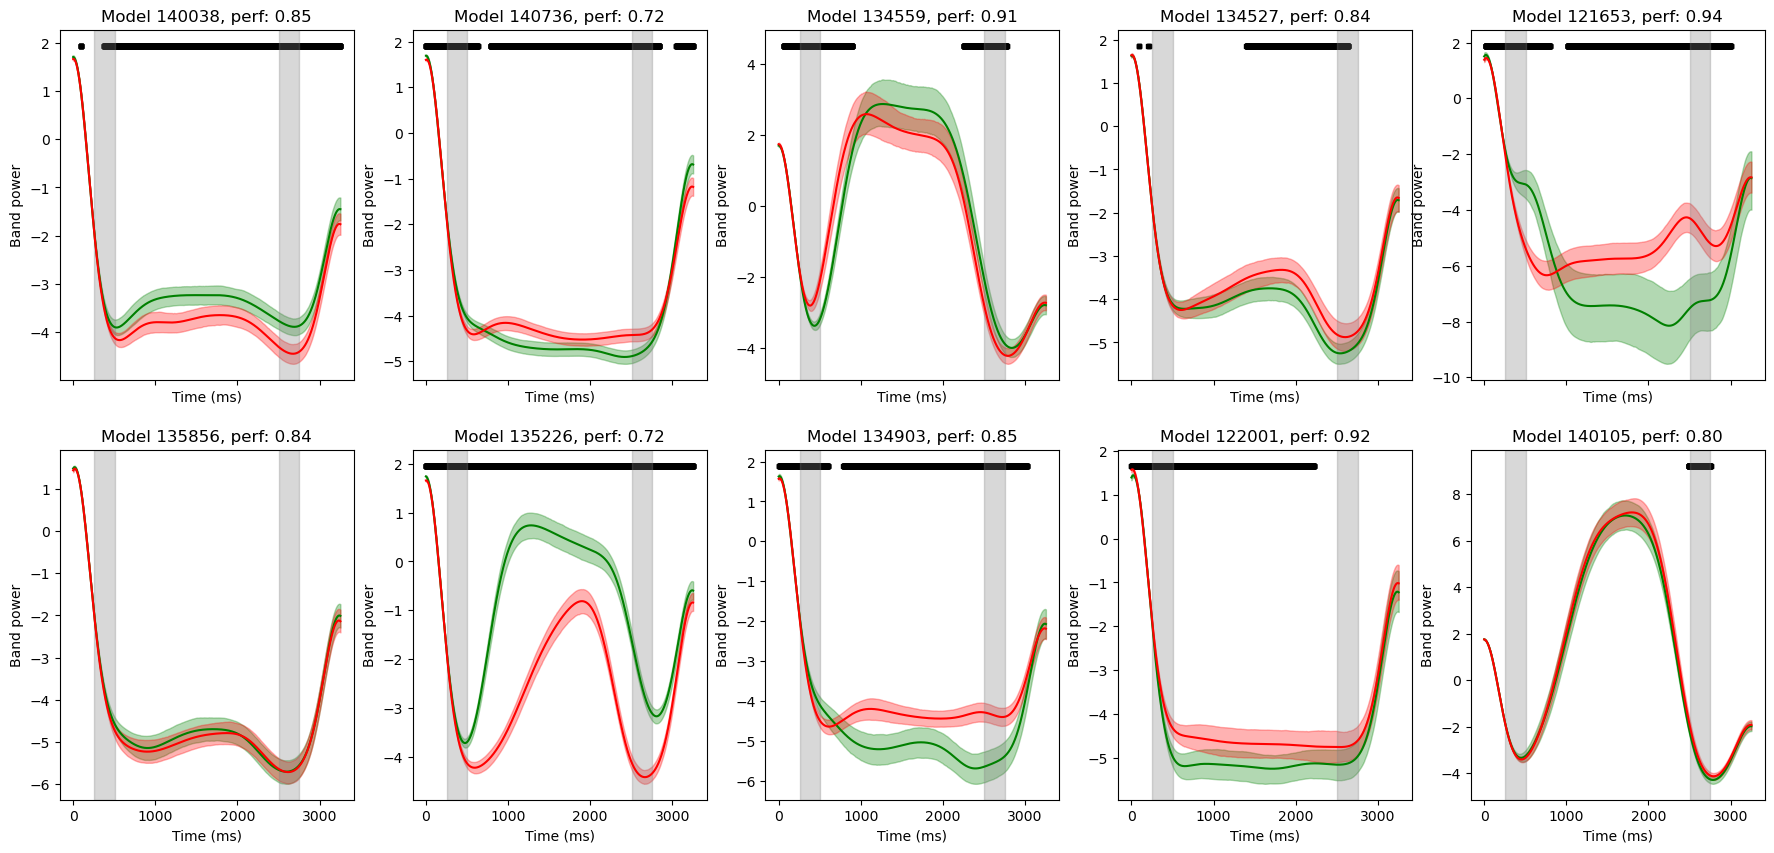

In [20]:
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

fig, axs = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models_select):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    # split by correct vs incorrect trials
    bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
    bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
    
    # plot with bootstrap CIs
    _ = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                ax = axs[i_model], all_models_dir=all_models_dir)
    
    

Skipping model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653 due to insufficient incorrect trials, n=0


Text(0.5, 0.98, 'Stimulus 1 = +1')

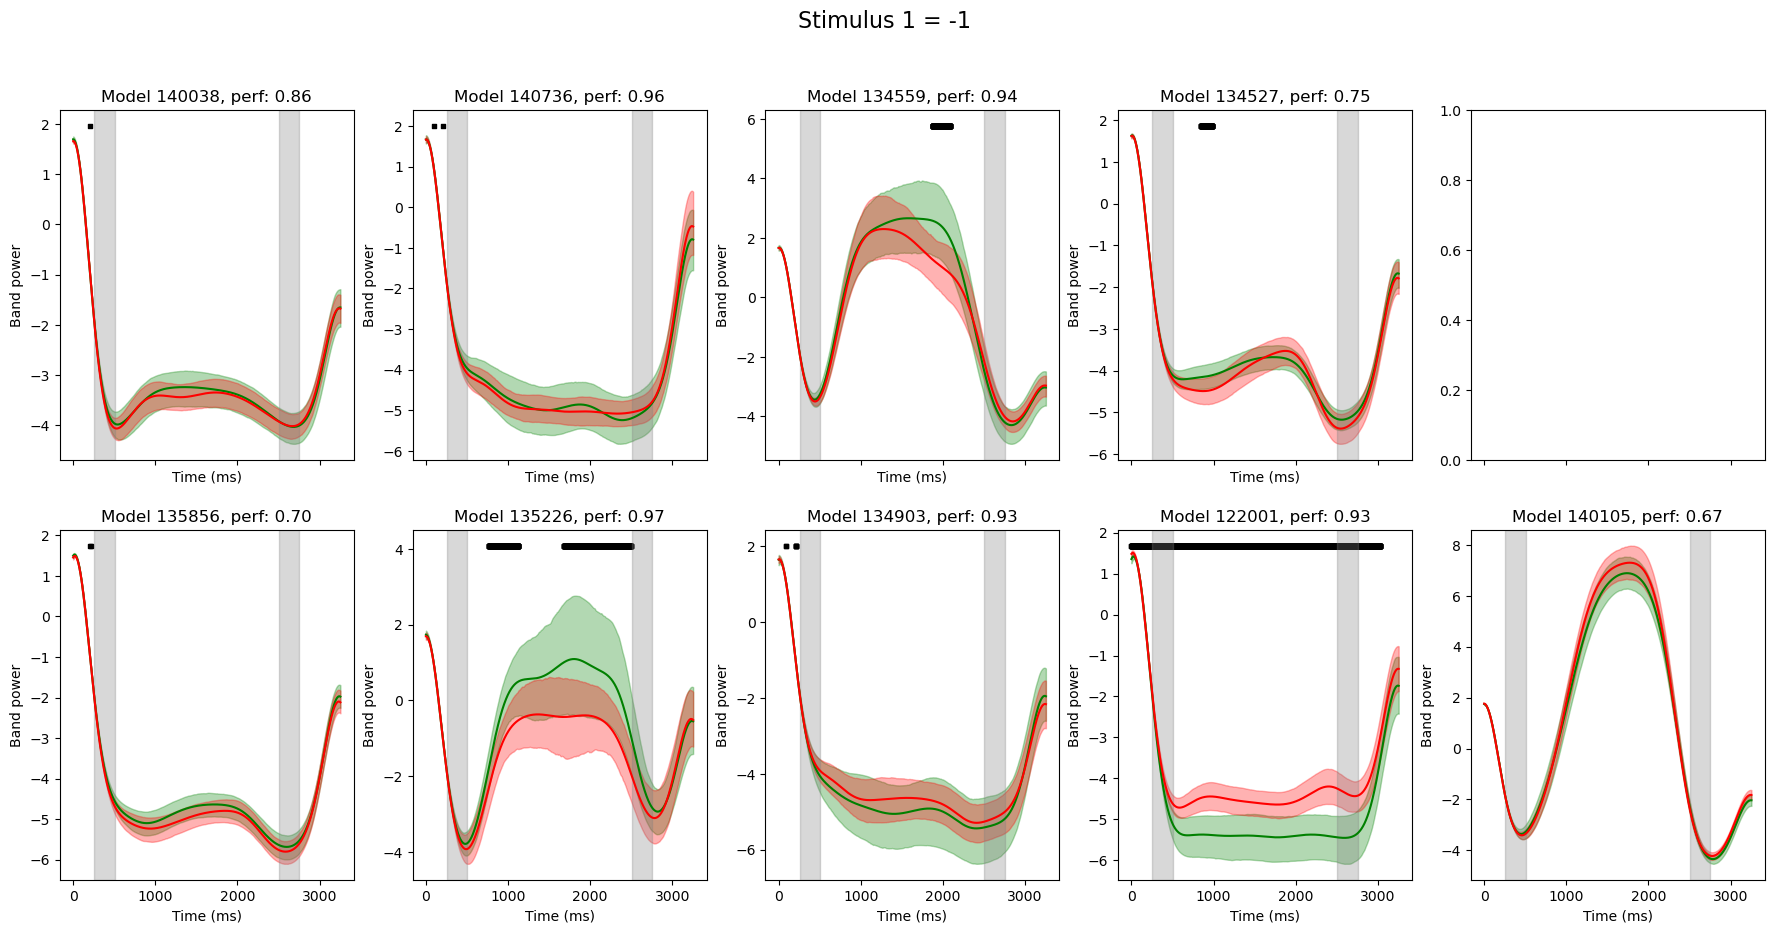

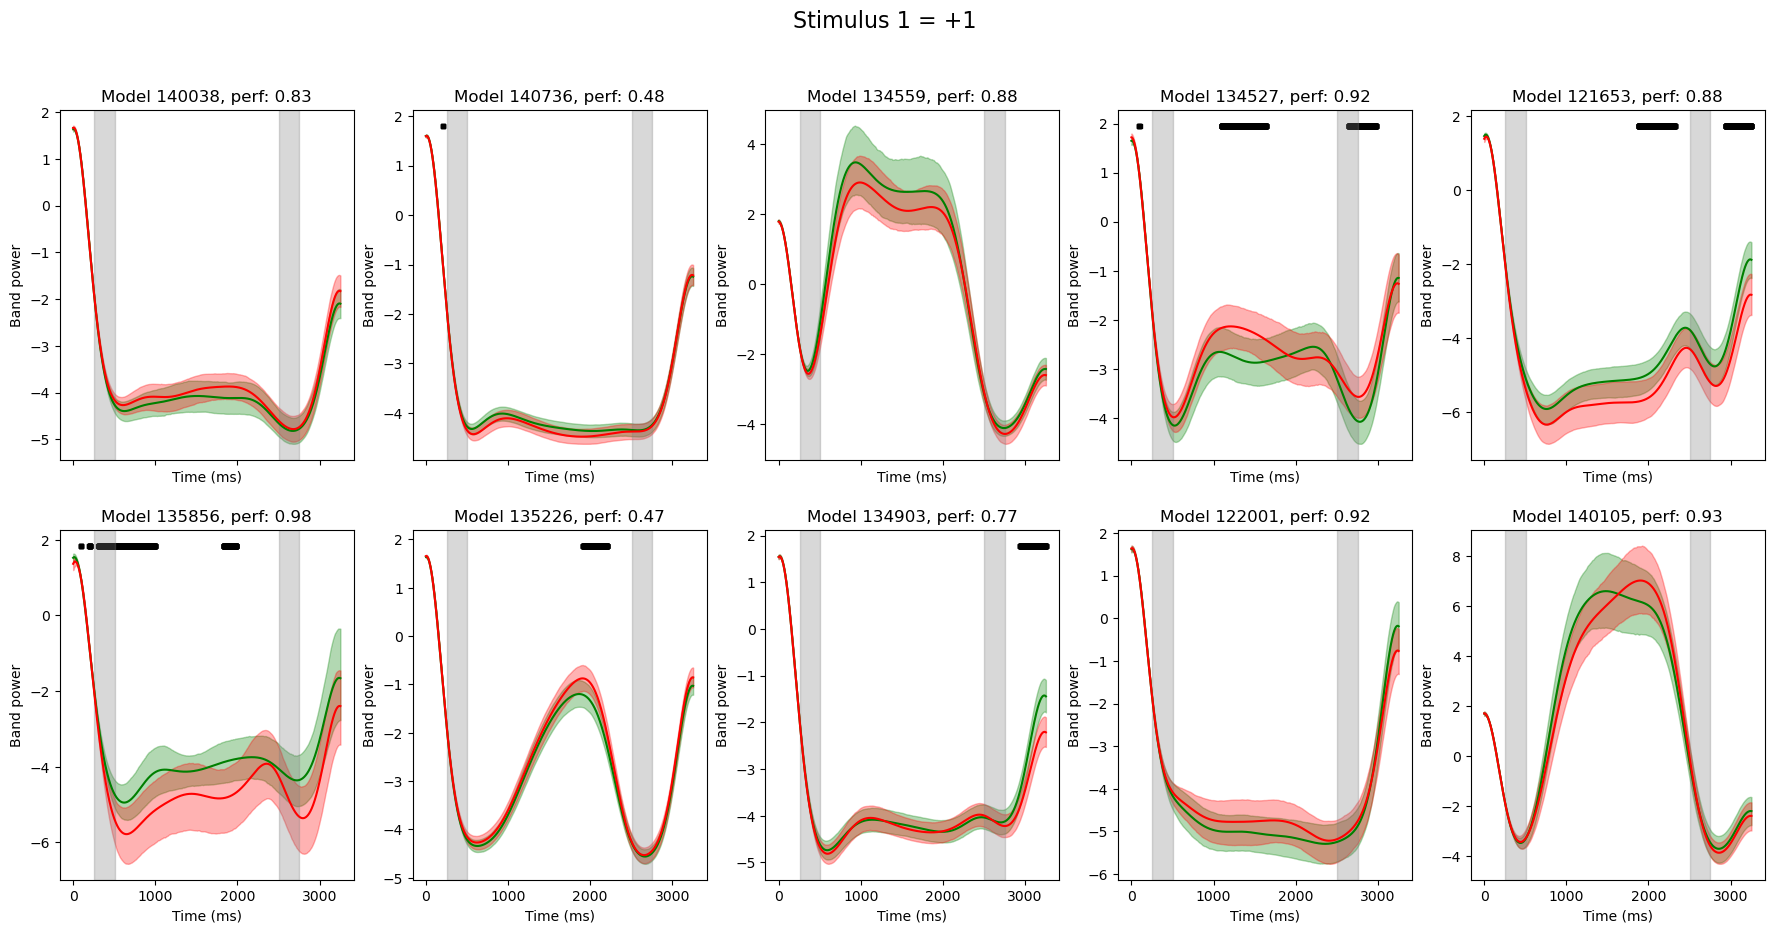

In [40]:
# splitting by the identity of the first stimulus, and then correct vs incorrect

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

stim1 = [-1, 1]

fig1, axs1 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs1 = axs1.flatten()
fig2, axs2 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs2 = axs2.flatten()
for i_model, model_name in enumerate(theta4_models_select):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    for j, s1 in enumerate(stim1):
        # split by correct vs incorrect trials
        bandpower_corr = bandpower[(trial_perfs==1) & (trial_labels[:,0] == s1),:].squeeze()
        bandpower_incorr = bandpower[(trial_perfs==0) & (trial_labels[:,0] == s1),:].squeeze()
        
        if np.sum((trial_perfs==0) & (trial_labels[:,0] == s1)) < 5: # skip if not enough incorrect trials
            print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum((trial_perfs==0) & (trial_labels[:,0] == s1))}')
            continue

        if j == 0:
            ax = axs1[i_model]
        else:
            ax = axs2[i_model]
        
        _ = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                        ax = ax, all_models_dir=all_models_dir, title=f'Model {model_name[-6:]}, perf: {np.sum((trial_perfs==1) & (trial_labels[:,0] == s1)) / np.sum(trial_labels[:,0] == s1):.2f}')

fig1.suptitle('Stimulus 1 = -1', fontsize=16)
fig2.suptitle('Stimulus 1 = +1', fontsize=16)
    

#### try doing LFP as exc or inh only

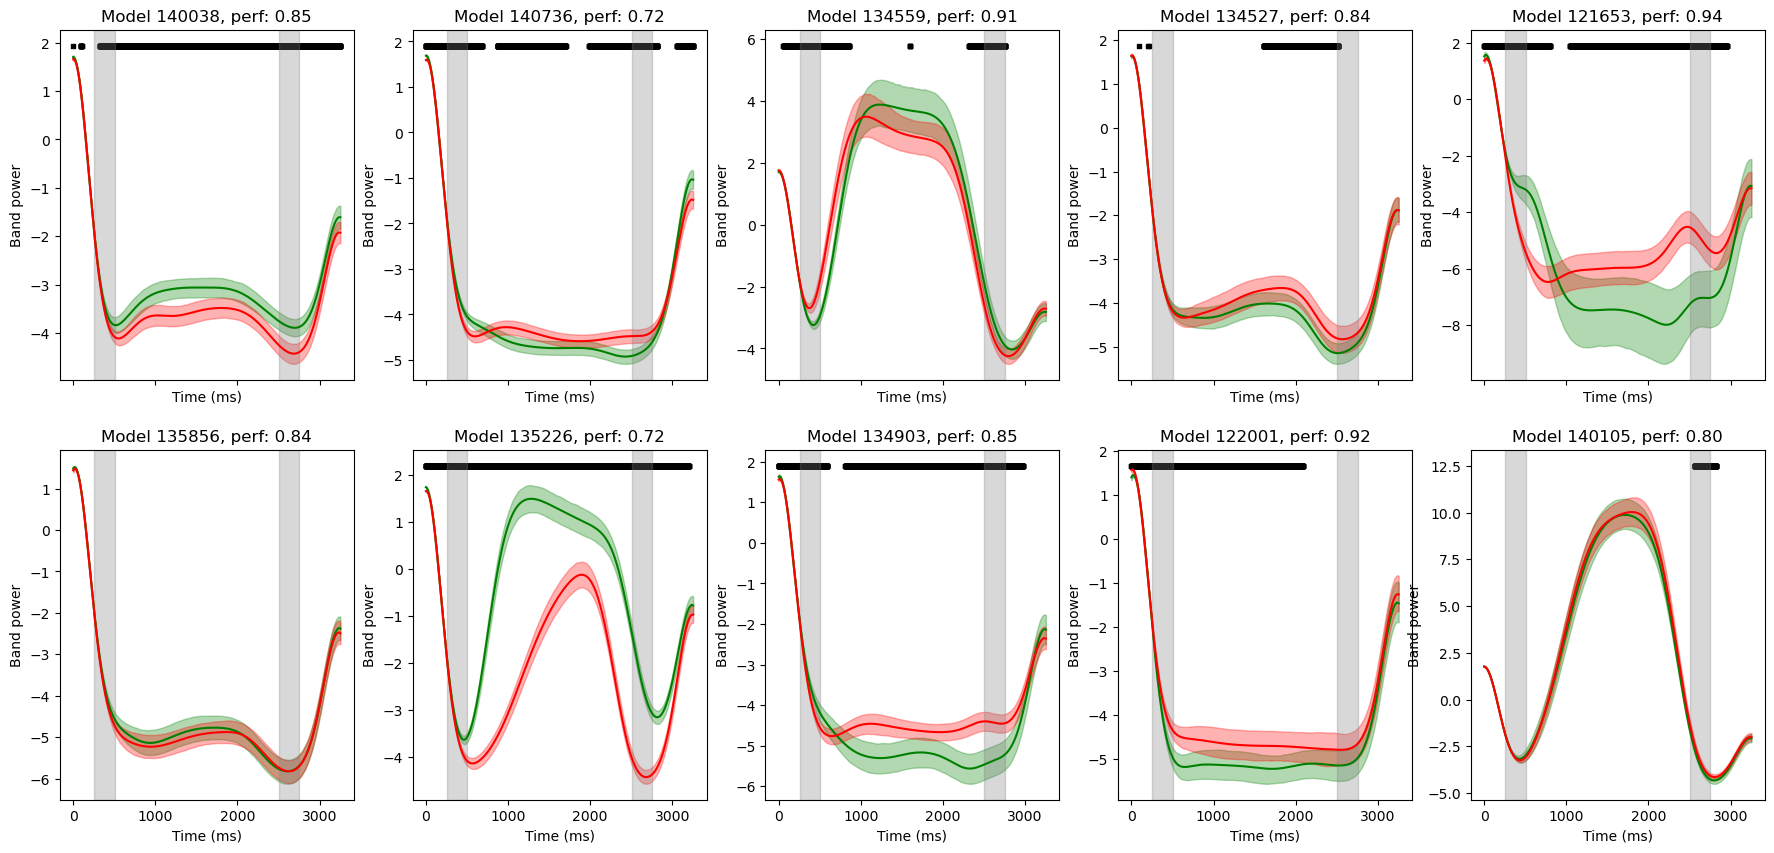

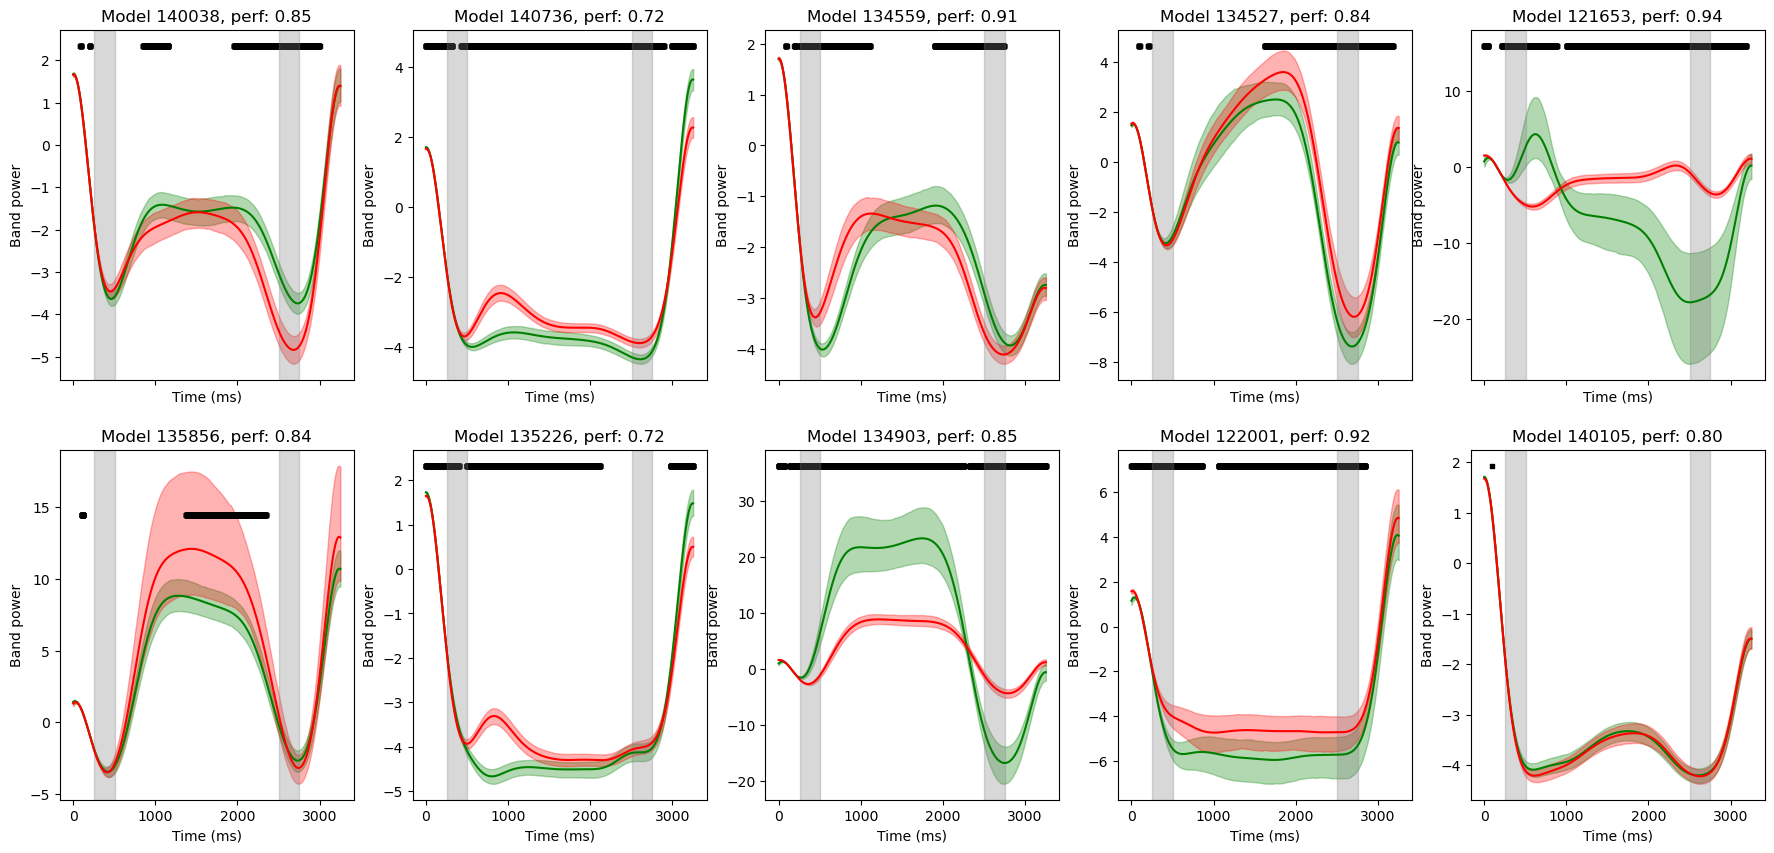

In [42]:
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

fig1, axs1 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs1 = axs1.flatten()
fig2, axs2 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs2 = axs2.flatten()

for i_model, model_name in enumerate(theta4_models_select):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power_exc, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data[:,exc_ind,:], axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower_exc, _ = lu.calc_band_power(power_exc, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])
    power_inh, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data[:,inh_ind,:], axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower_inh, _ = lu.calc_band_power(power_inh, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    for j, celltype in enumerate(['Excitatory', 'Inhibitory']):
        if celltype == 'Excitatory':
            bandpower = bandpower_exc
        else:
            bandpower = bandpower_inh

        if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
            print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
            continue
        
        if j == 0:
            ax = axs1[i_model]
        else:
            ax = axs2[i_model]
        ax.set_title(f'Model {model_name[-6:]}, perf: {np.mean(trial_perfs):.2f}, {celltype[:3]}')
        
        # split by correct vs incorrect trials
        bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
        bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
        
        # plot with bootstrap CIs
        _ = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                    ax = ax, all_models_dir=all_models_dir)
        
        
 

### Same, but no z-scoring anywhere

In [17]:
# rename files

for model_name in theta4_dirs:
    model_dir = os.path.join(all_models_dir, model_name)
    data_files = ld.find_files_keywords(model_dir, ['noisegaussian'])
    print(data_files)
    for f in data_files:
        new_f = f.replace(f'data_noisegaussian_raw_delay400', 'data_raw_delay400noisegaussianhalf')
        os.rename(f, new_f)
        print(f'Renamed {f} to {new_f}')

['/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhvdata_noisegaussian_raw_delay400.mat', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/timingdata_noisegaussian_raw_delay400.mat', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neuraldata_noisegaussian_raw_delay400.mat']
Renamed /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhvdata_noisegaussian_raw_delay400.mat to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhvdata_raw_delay400noisegaussia

Skipping model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450 due to insufficient incorrect trials, n=1


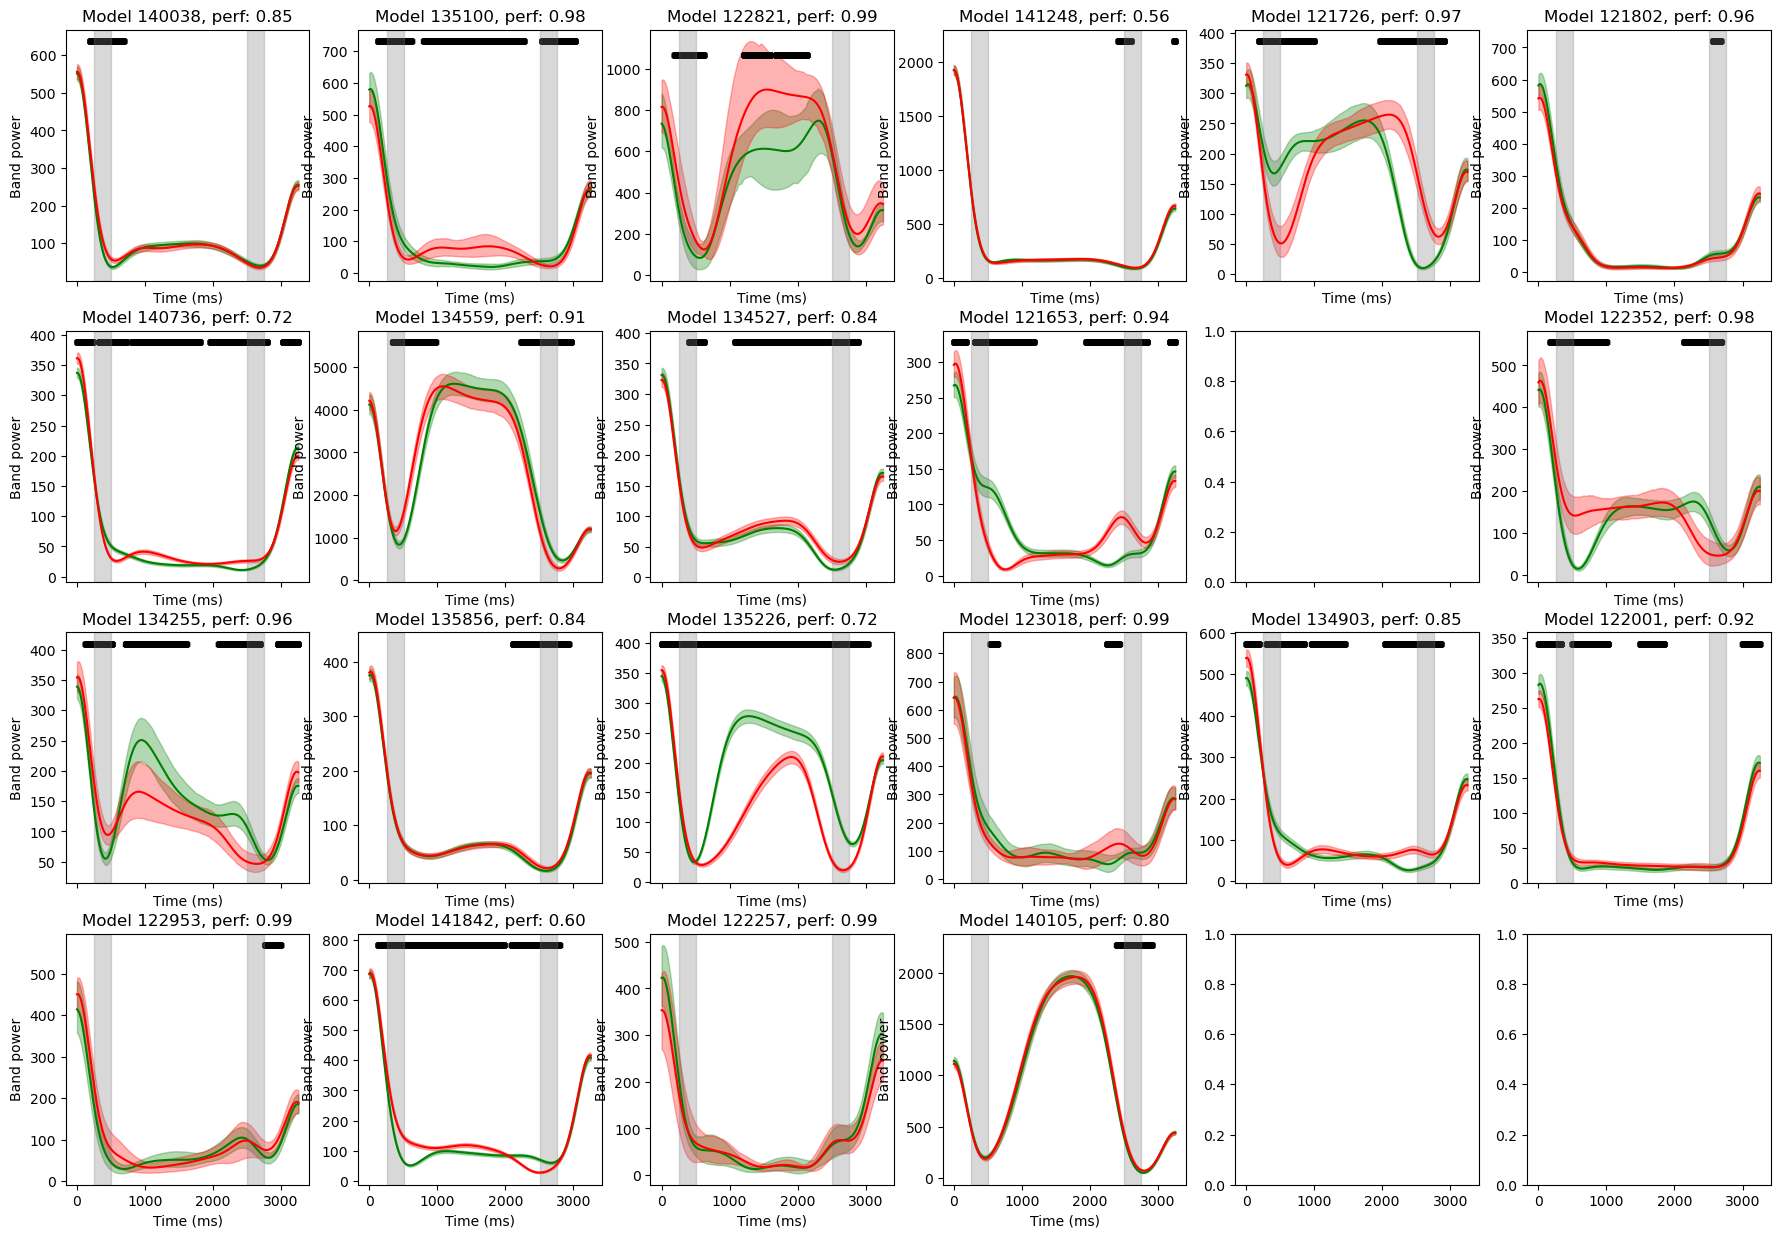

In [11]:
condn_phrase = 'data_raw_delay400'

importlib.reload(lu)

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

corrs = []
incorrs = []
corr_CIs = []
incorr_CIs = []
ps = []

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_dirs):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, all_models_dir=all_models_dir)

    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], 
                                             zscore_band=False)

    # split by correct vs incorrect trials
    bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
    bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
    
    if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
        print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
        continue
    
    # plot with bootstrap CIs
    _, corr, incorr, corr_CI, incorr_CI, p = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, 
                                                                         condn_phrase, all_models_dir=all_models_dir,
                                                                         ax = axs[i_model])

    corrs.append(corr)
    incorrs.append(incorr)
    corr_CIs.append(corr_CI)
    incorr_CIs.append(incorr_CI)
    ps.append(p)
    

Skipping model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122257 due to insufficient incorrect trials, n=4


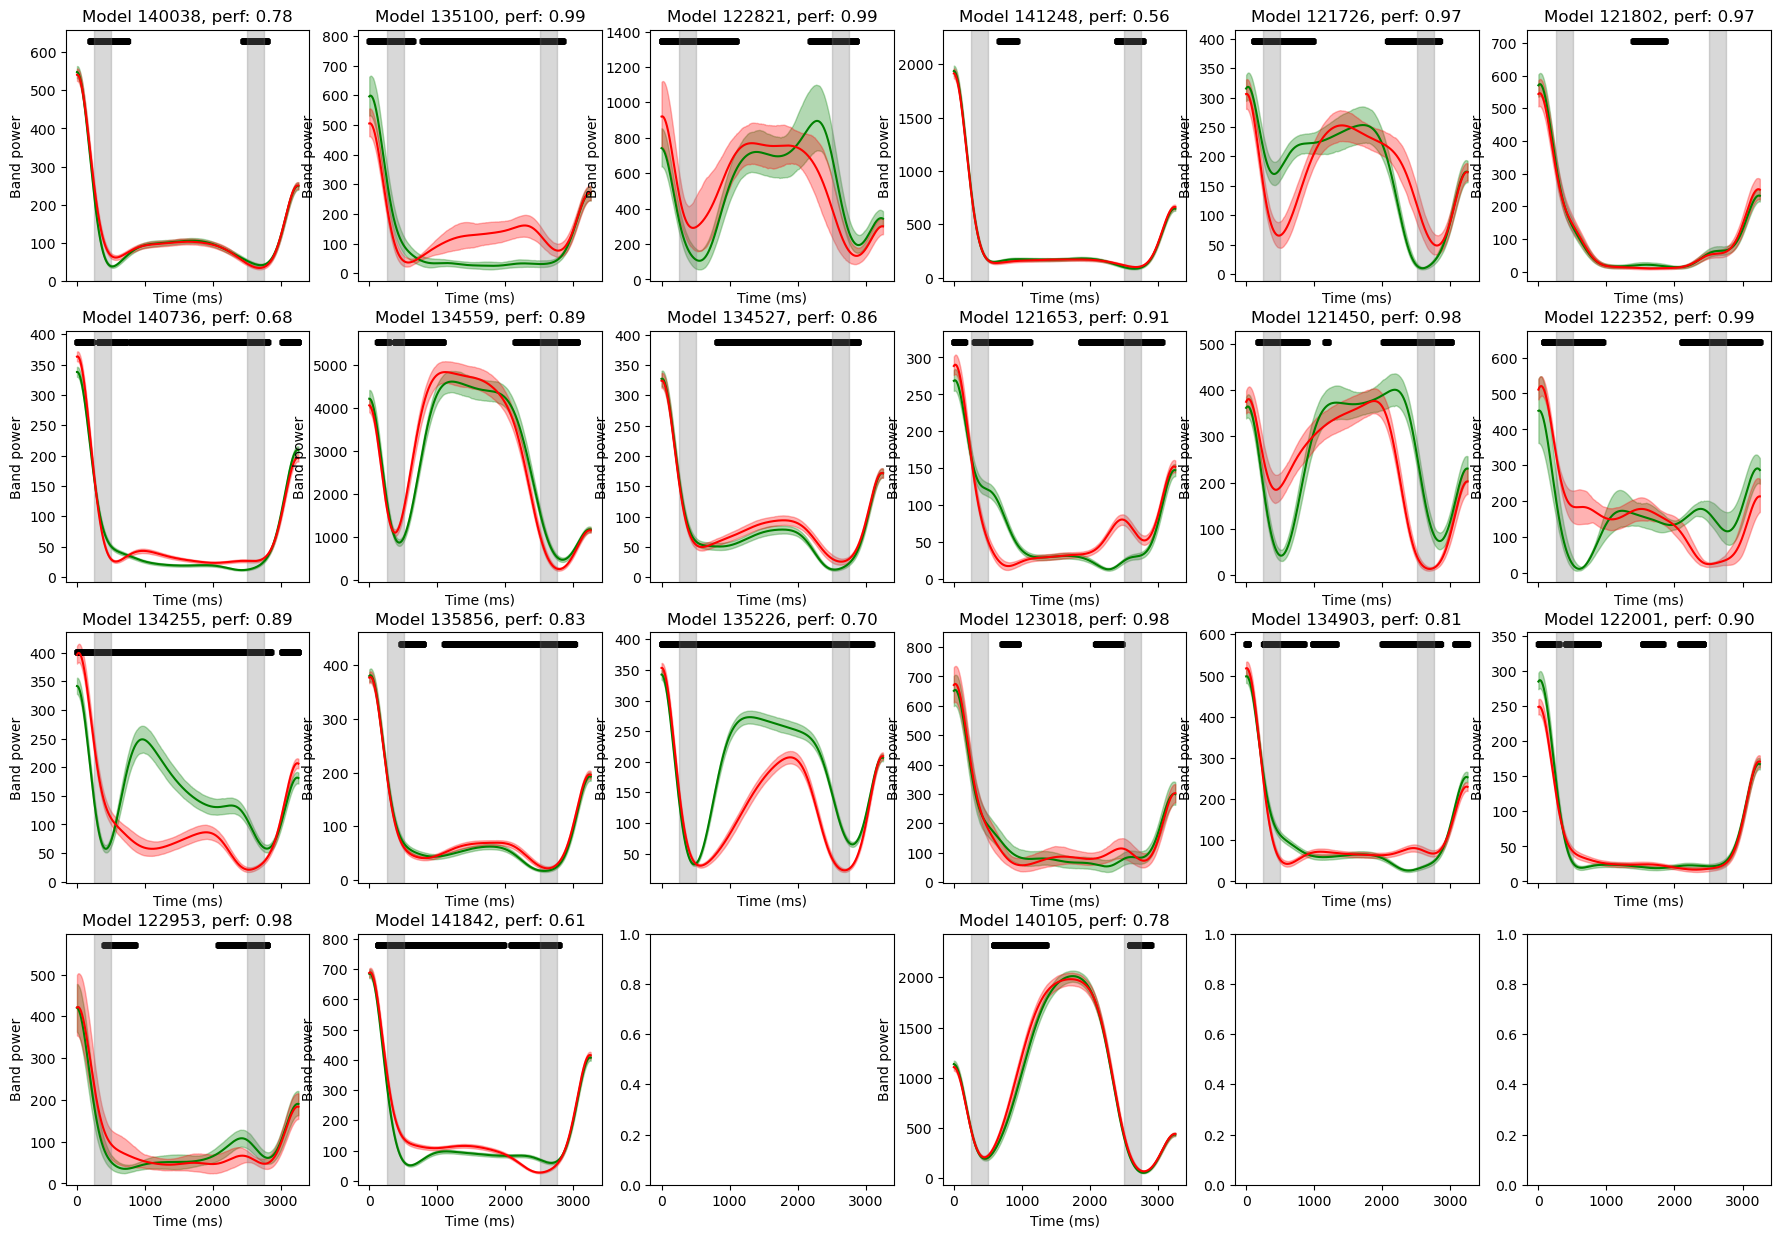

In [ ]:
# oops this is the plot for with gaussian noise

importlib.reload(lu)

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

corrs = []
incorrs = []
corr_CIs = []
incorr_CIs = []
ps = []

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_dirs):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], 
                                             zscore_band=False)

    # split by correct vs incorrect trials
    bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
    bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
    
    if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
        print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
        continue
    
    # plot with bootstrap CIs
    _, corr, incorr, corr_CI, incorr_CI, p = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                ax = axs[i_model], all_models_dir=all_models_dir)
    
    corrs.append(corr)
    incorrs.append(incorr)
    corr_CIs.append(corr_CI)
    incorr_CIs.append(incorr_CI)
    ps.append(p)
    

In [8]:
model_name = theta4_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

ld.find_files_keywords(model_dir, ['bhvdata', 'delay400'])

['/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhvdata_noisegaussian_raw_delay400.mat',
 '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhvdata_raw_delay400.mat']